<a href="https://colab.research.google.com/github/felipeedubravo/Codigos/blob/main/ecommerce_estatistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de Análise Exploratória e Machine Learning - E-commerce
**Aluno:** Felipe Eduardo da Silva França
**Objetivo:** Realizar EDA, correlações, visualizações avançadas e modelo preditivo de Regressão Linear.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo
sns.set_theme(style="whitegrid")

# Leitura dos dados
df = pd.read_csv('ecommerce_estatistica.csv')
df.head()

,Unnamed: 0,Título,Nota,N_Avaliações,Desconto,Marca,Material,Gênero,Temporada,Review1,...,Nota_MinMax,N_Avaliações_MinMax,Desconto_MinMax,Preço_MinMax,Marca_Cod,Material_Cod,Temporada_Cod,Qtd_Vendidos_Cod,Marca_Freq,Material_Freq
0,1,Kit 10 Cuecas Boxer Lupo Cueca Box Algodão Mas...,4.5,3034.0,18.0,lupo,algodão,Masculino,outono/inverno,As cuecas são boas; porém você percebe na cost...,...,0.814815,0.334178,0.213115,0.378585,463,25,3,10000.0,0.042292,0.176444
1,2,Kit Com 10 Cuecas Boxer Algodão Sem Costura Zo...,4.7,5682.0,20.0,zorba,algodão,Masculino,não definido,O tecido é bom e são confortáveis. Só que a nu...,...,0.888889,0.625937,0.245902,0.322329,838,25,1,50000.0,0.009095,0.176444
2,3,Kit 10 Cuecas Boxer Mash Algodão Cotton Box Or...,4.6,1700.0,22.0,mash,algodão,Masculino,primavera/verão,"As cuecas são boas, porém meu marido usa g e p...",...,0.851852,0.187197,0.278689,0.372617,494,25,7,10000.0,0.010914,0.176444
3,4,Kit 3 Short Jeans Feminino Cintura Alta Barato...,4.4,507.0,9.0,menina linda,jean,Feminino,primavera/verão,Estou encantada com essas peças!.\nOs shorts s...,...,0.777778,0.055751,0.065574,0.201767,509,74,7,1000.0,0.010005,0.025466
4,5,Blusa + Calça Térmica Treino Futebol Criança I...,4.7,58.0,5.0,roupa zero grau,termico unissex,Sem gênero infantil,outono/inverno,"Produto ótimo , mesmo após várias lavagens não...",...,0.888889,0.006280,0.000000,0.114508,669,166,3,100.0,0.002274,0.000910


In [9]:
# Análise de dados
print("Informações gerais do DataFrame:")
print("-"*40)
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])
print("-"*40)
df.info()
print("-"*40)
print("\nValores Nulos:\n", df.isnull().sum())
print("-"*40)
print("\nValores Duplicados:", df.duplicated().sum())
print("-"*40)


Informações gerais do DataFrame:
----------------------------------------
Linhas: 295
Colunas: 24
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           295 non-null    int64  
 1   Título               295 non-null    object 
 2   Nota                 295 non-null    float64
 3   N_Avaliações         295 non-null    float64
 4   Desconto             295 non-null    float64
 5   Marca                295 non-null    object 
 6   Material             295 non-null    object 
 7   Gênero               295 non-null    object 
 8   Temporada            295 non-null    object 
 9   Review1              295 non-null    object 
 10  Review2              295 non-null    object 
 11  Review3              295 non-null    object 
 12  Qtd_Vendidos         295 non-null    object 
 13  P

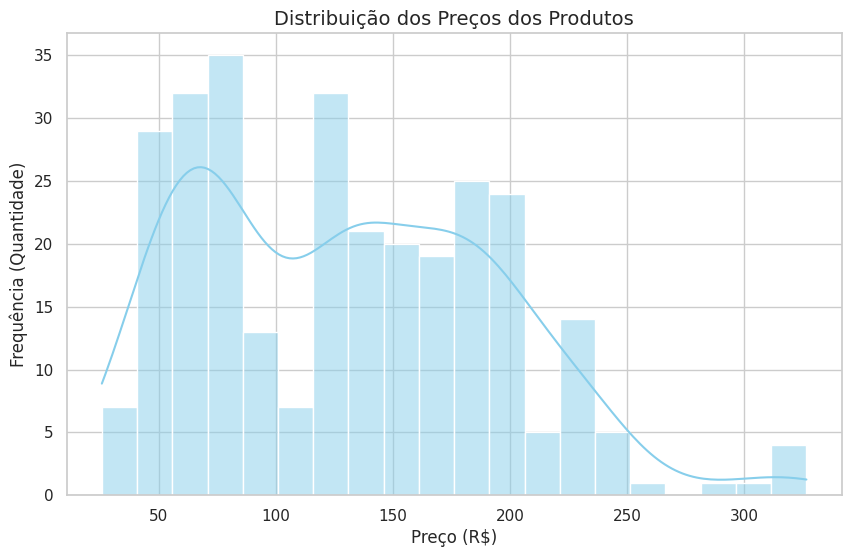

In [11]:
# 1. Gráfico de Histograma (Distribuição de Preços)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Preço', bins=20, color='skyblue', kde=True)
plt.title('Distribuição dos Preços dos Produtos', fontsize=14)
plt.xlabel('Preço (R$)', fontsize=12)
plt.ylabel('Frequência (Quantidade)', fontsize=12)
plt.show()

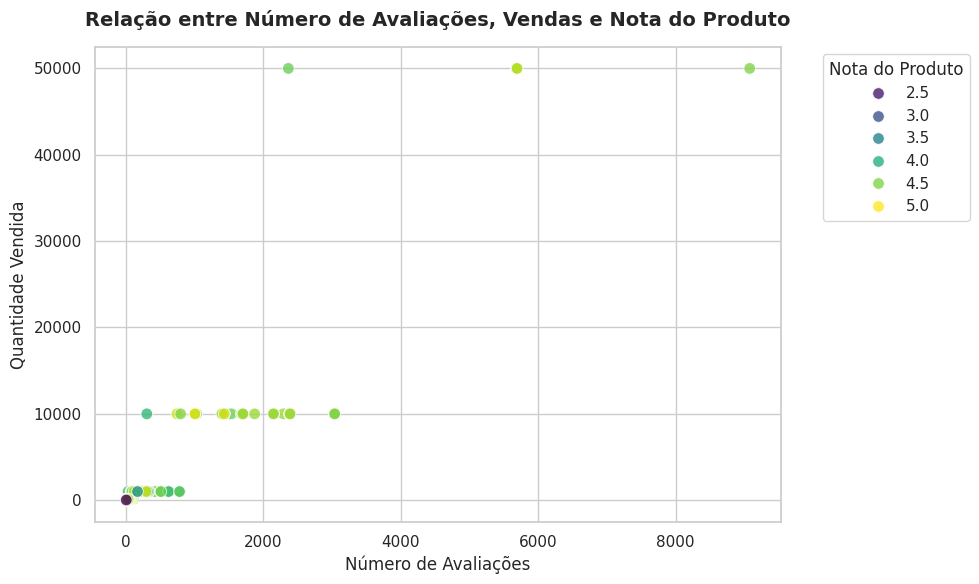

In [12]:
# 2. Gráfico de Dispersão Avançado (Avaliações vs. Vendas + Terceira Variável)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='N_Avaliações', y='Qtd_Vendidos_Cod', hue='Nota', palette='viridis', alpha=0.8,s=70)
plt.title('Relação entre Número de Avaliações, Vendas e Nota do Produto', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Avaliações', fontsize=12)
plt.ylabel('Quantidade Vendida', fontsize=12)
plt.legend(title='Nota do Produto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


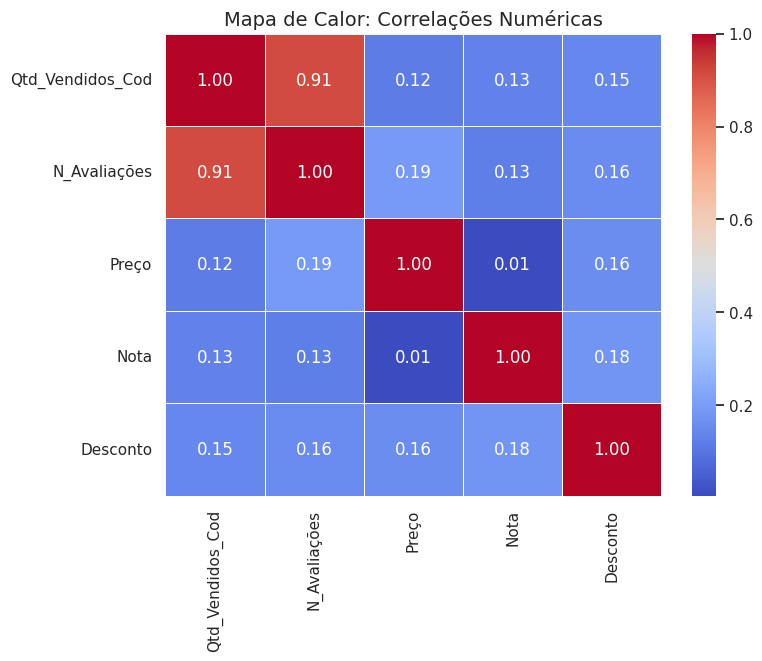

In [13]:
# 3. Mapa de Calor (Correlação entre Variáveis Numéricas)
plt.figure(figsize=(8, 6))
colunas_num = df[['Qtd_Vendidos_Cod', 'N_Avaliações', 'Preço', 'Nota', 'Desconto']]
sns.heatmap(colunas_num.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor: Correlações Numéricas', fontsize=14)
plt.show()

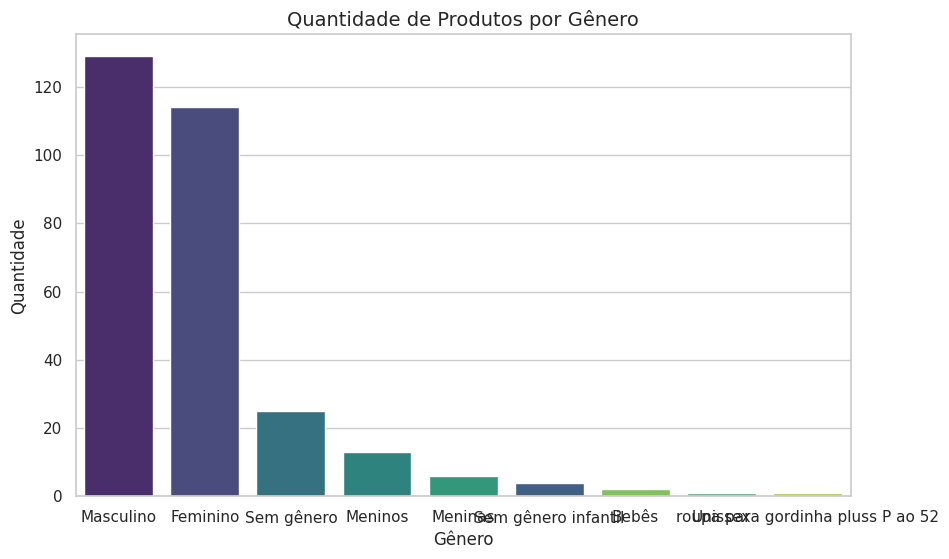

In [17]:
# 4. Gráfico de Barra (Quantidade de Produtos por Gênero)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Gênero', hue='Gênero', order=df['Gênero'].value_counts().index, palette='viridis', legend=False)
plt.title('Quantidade de Produtos por Gênero', fontsize=14)
plt.xlabel('Gênero', fontsize=12)
plt.ylabel('Quantidade', fontsize=12)
plt.show()


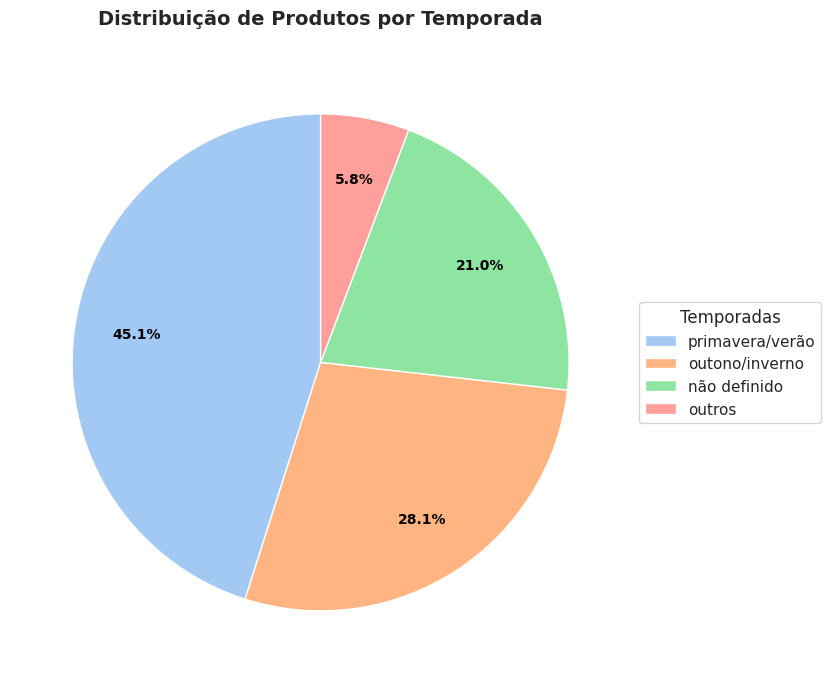

In [14]:
# 5. Gráfico de Pizza (Participação por Temporada)
plt.figure(figsize=(10, 7))
contagem_temporada = df['Temporada'].value_counts()

# Agrupa categorias menores que 3% em "Outros" para evitar poluição visual
limite_percentual = 0.03 * contagem_temporada.sum()
principais = contagem_temporada[contagem_temporada >= limite_percentual]
outros = pd.Series({'outros': contagem_temporada[contagem_temporada < limite_percentual].sum()})
contagem_ajustada = pd.concat([principais, outros])

wedges, texts, autotexts = plt.pie(contagem_ajustada, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'),pctdistance=0.75)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_weight('bold')
    autotext.set_fontsize(10)

plt.legend( wedges, contagem_ajustada.index, title="Temporadas", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Distribuição de Produtos por Temporada', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

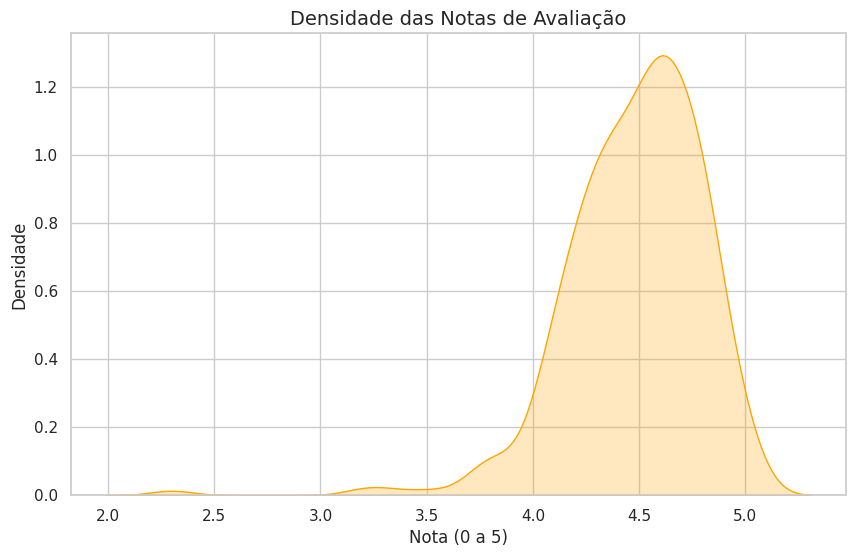

In [15]:
# 6. Gráfico de Densidade (Concentração das Notas)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Nota', fill=True, color='orange')
plt.title('Densidade das Notas de Avaliação', fontsize=14)
plt.xlabel('Nota (0 a 5)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.show()

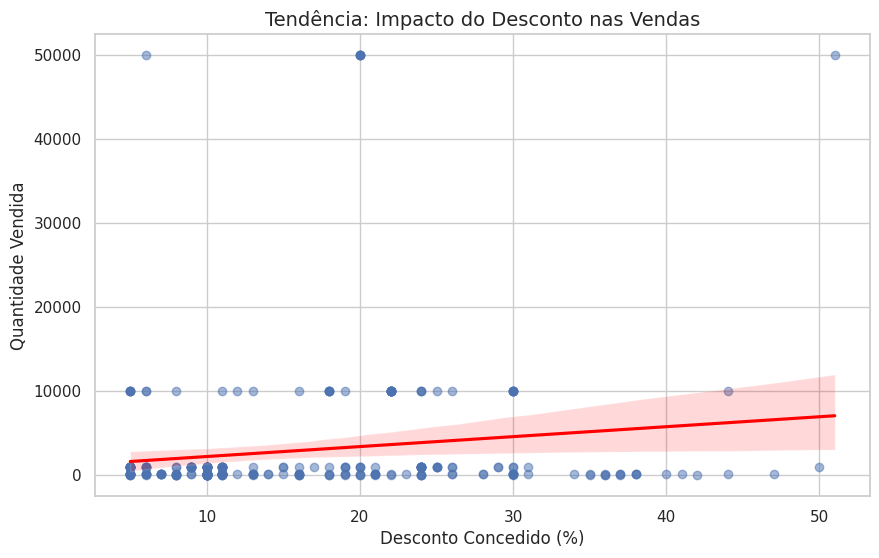

In [16]:
# 7. Gráfico de Regressão (Impacto do Desconto nas Vendas)
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Desconto', y='Qtd_Vendidos_Cod', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Tendência: Impacto do Desconto nas Vendas', fontsize=14)
plt.xlabel('Desconto Concedido (%)', fontsize=12)
plt.ylabel('Quantidade Vendida', fontsize=12)
plt.show()